In [15]:
from base_m_noise import *
import base_m_noise; importlib.reload(base_m_noise)

<module 'base_m_noise' from '/Users/tphillips/multiplicative_noise/python/base_m_noise.py'>

In [17]:
scale = 1
om, D1, D2, T = 1, 1, 0, 10000
sig = -1

x_lin_i1, P_lin_i1 = stat_den_sde(om, D1, D2, T, f_lin, g_lin, dt=0.001, osc=False, lim=np.pi, sig=sig)  
x_osc_i1, P_osc_i1 = stat_den_sde(om, D1, D2, T, f_sin, g, dt=0.001, osc=True, lim=np.pi, sig=sig) 
P_lin_i1_ = 0.5*np.array(P_lin_i1)

dt2, T2 = 0.000001, 15   
tl, xl_i1 = SDE_ev1(om, D1, 0, T2, f_, g, dt2, xinit=1, osc=True)
detlist = osc_mod(om*np.array(tl))

D1 = 0.5

x_lin_i5, P_lin_i5 = stat_den_sde(om, D1, D2, T, f_lin, g_lin, dt=0.001, osc=False, lim=np.pi, sig=sig)
x_osc_i5, P_osc_i5 = stat_den_sde(om, D1, D2, T, f_sin, g, dt=0.001, osc=True, lim=np.pi, sig=sig)
P_lin_i5_ = 0.5*np.array(P_lin_i5)

### Import analytical results from Mathematica ###
#df=pd.read_csv("/Users/tphillips/multiplicative_noise/linear_Dm5_n0_m1.txt", sep='\t', header=None)
#df.columns=['phi', 'P']
#df = df.sort_values(by=['phi'])
#x_i5, y_i5 = df['phi'][::10], scale*np.array(df['P'][::10])

tl_i5, xl_i5 = SDE_ev1(om, D1, 0, T2, f_, g, dt2, xinit=1, osc=True)

D1 = 1

x_lin_s1, P_lin_s1 = stat_den_strat_l(om, D1, D2, T, f_lin, g_lin, dt=0.001, osc=False, lim=np.pi, lin='zero', sig=-sig, xinit=-np.pi+0.1)  
x_osc_s1, P_osc_s1 = stat_den_strat_s(om, D1, D2, T, f_sin, g, dt=0.001, lim=np.pi, sig=sig, xinit=-np.pi+0.1) 
P_lin_s1_ = 0.5*np.array(P_lin_s1)

D1 = 5

x_lin_s5, P_lin_s5 = stat_den_strat_l(om, D1, D2, T, f_lin, g_lin, dt=0.001, osc=False, lim=np.pi, lin='zero', sig=-sig, xinit=-np.pi+0.1)  
x_osc_s5, P_osc_s5 = stat_den_strat_s(om, D1, D2, T, f_sin, g, dt=0.001, lim=np.pi, sig=sig, xinit=-np.pi+0.1) 

df = pd.DataFrame({'x': x_lin_i1, 'P_lin_i1': P_lin_i1, 'P_osc_i1': P_osc_i1,  
                   'P_lin_i5': P_lin_i5, 'P_osc_i5': P_osc_i5, 'P_lin_s1': P_lin_s1,  
                   'P_osc_s1': P_osc_s1, 'P_lin_s5': P_lin_s5, 'P_osc_s5': P_osc_s5})
df.to_csv('ito_v_P_strat_D1_D5_sigm1.csv', index=False) 
 
df = pd.DataFrame({'tl': tl, 'xl_i1': xl_i1, 'xl_i5': xl_i5}) 
df.to_csv('ito_v_tplot_strat_D1_D5_sigm1.csv', index=False) 

In [ ]:
df1 = pd.read_csv('ito_v_P_strat_D1_D5.csv') 
df2 = pd.read_csv('ito_v_tplot_strat_D1_D5.csv') 

x = df1['x']
P_lin_i1, P_osc_i1, P_lin_i5, P_osc_i5 = df1['P_lin_i1'], df1['P_osc_i1'], df1['P_lin_i5'], df1['P_osc_i5']
P_lin_s1, P_osc_s1, P_lin_s5, P_osc_s5 = df1['P_lin_s1'], df1['P_osc_s1'], df1['P_lin_s5'], df1['P_osc_s5']

tl, xl_i1, xl_i5 = df2['tl'], df2['xl_i1'], df2['xl_i5']

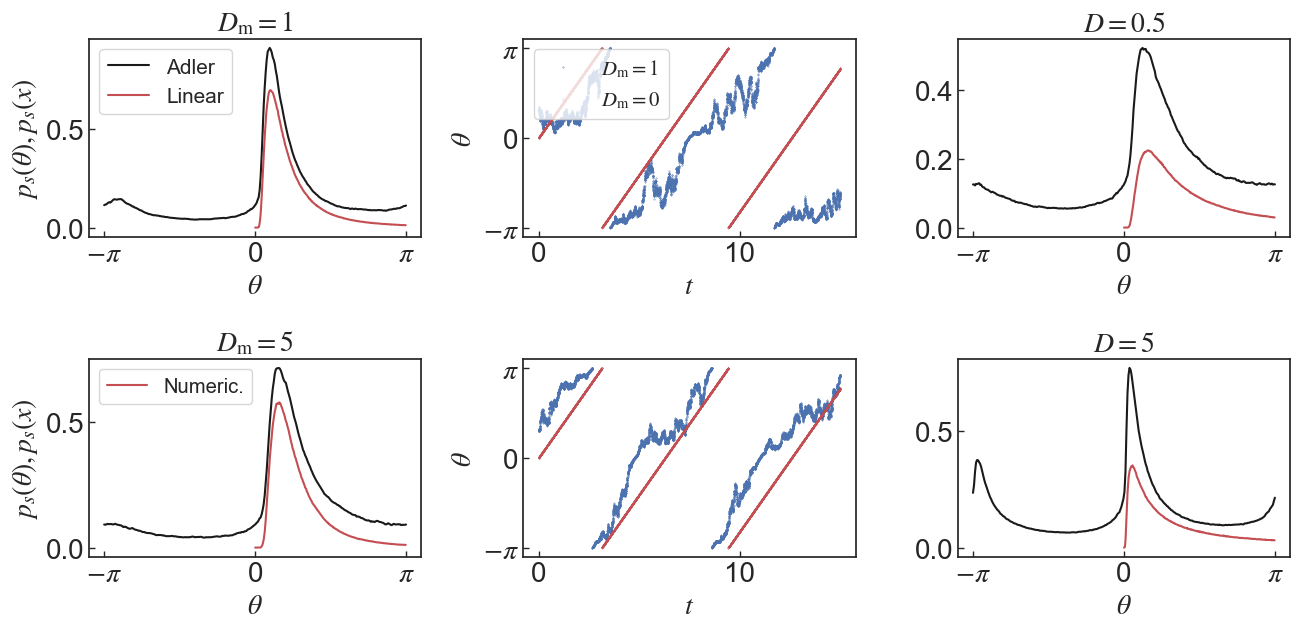

In [18]:


params = {'xtick.labelsize': 20, 'ytick.labelsize': 20,
              'axes.labelsize': 20, 'axes.titlesize': 20,  
              'font.size': 20, 'legend.handlelength': 2}

sns.set_theme(style="white", rc=params)
f, ax = plt.subplots(2, 3, figsize=(13.4, 6.7)) 

P_lin_i1_ = P_lin_i1 
x2 = np.arange(-np.pi, np.pi, round(2*np.pi/300, 3))

#
ax[0,0].plot(x2, P_osc_i1, 'k', label='Adler')  
ms = 6.3 

scale = 0.7*(np.max(P_lin_i1_)/np.max(P_osc_i1)/2) 
ax[0,0].plot(x_lin_i1, scale*P_lin_i1_, 'r', label='Linear')     # x_lin_i1

#df=pd.read_csv("/Users/tphillips/multiplicative_noise/c++/DATA/stat_nFPE_om1_Dm2_Dadd0.04.dat",sep=" ",header=None)
#df = df.dropna(axis='columns',how='all')
#df.columns=['phi','D1','D2','P', 'Pn', 'I', 'PdB']
#y = np.array(df['Pn'])
#x = np.arange(-np.pi, np.pi, 2*np.pi/len(y))
#ax[0,0].plot(x[::10], y[::10], 'k+', markersize=5, mec = 'k')

#ax[0,0].plot(x_i1, y_i1, 'ro', markersize=5, mec = 'k')
ax[0,0].tick_params(bottom=True, left=True)
ax[0,0].tick_params(direction="in", length=4, width=1, grid_alpha=0.5)
#ax[0,0].legend(fontsize=15, loc='upper left')
ax[0,0].set_title(r"$D_{\text{m}} = 1$")
#ax[0,0].set_ylim([-0.02, 0.75])
labels(ax[0,0], ylab='theta_x')

###
P_lin_i5_ = P_lin_i5
scale = 0.6*(np.max(P_lin_i5_)/np.max(P_osc_i5)/2)     
ax[1,0].plot(x2, P_osc_i5, 'k')   
ax[1,0].plot(x_lin_i5, scale*np.array(P_lin_i5_), 'r', label='Numeric.')  
#ax[1,0].plot(x2[::5], P_osc_i5_an[::5], 'k+', markersize=ms, mec = 'k')  

#df=pd.read_csv("/Users/tphillips/multiplicative_noise/c++/DATA/stat_nFPE_om1_Dm5_Dadd0.04.dat",sep=" ",header=None)
#df = df.dropna(axis='columns', how='all')
#df.columns=['phi','D1','D2','P', 'Pn', 'I', 'PdB']
#y = np.array(df['Pn'])
#x = np.arange(-np.pi, np.pi, 2*np.pi/len(y))

#ax[0,1].plot(x_i5, y_i5, 'ro', markersize=5, mec = 'k')
ax[1,0].tick_params(bottom=True, left=True)
ax[1,0].tick_params(direction="in", length=4, width=1, grid_alpha=0.5)
ax[1,0].set_title(r"$D_{\text{m}}  = 5$")

ax[0,0].legend(fontsize=15, loc='upper left')
labels(ax[1,0], ylab='theta_x')
ax[1,0].legend(fontsize=14.5, loc='upper left')

#-----
scale = 0.5*(np.max(P_lin_i5_)/np.max(P_osc_i5)/2) 
om = 1
detlist = osc_mod(om*np.array(tl))

ax[0,1].plot(tl, xl_i1, '.', markersize=0.6, label=r'$D_{\text{m}} = 1$')
ax[0,1].plot(tl, detlist, 'r.', markersize=0.2, label=r'$D_{\text{m}} = 0$')
ax[0,1].set_yticks([-np.pi, 0, np.pi])
ax[0,1].set_yticklabels([r'$-\pi$', r'0', r'$\pi$'])
ax[0,1].set_xlabel(r'$t$')
ax[0,1].set_ylabel(r'$\theta$')
ax[0,1].tick_params(bottom=True, left=True)
ax[0,1].tick_params(direction="in", length=4, width=1, grid_alpha=0.5)

ax[0,1].legend(fontsize=15, loc='upper left')

#-----

ax[1,1].plot(tl, xl_i5, '.', markersize=0.6)
ax[1,1].plot(tl, detlist, 'r.', markersize=0.2)
ax[1,1].set_yticks([-np.pi, 0, np.pi])
ax[1,1].set_yticklabels([r'$-\pi$', r'0', r'$\pi$'])
ax[1,1].set_xlabel(r'$t$')
ax[1,1].set_ylabel(r'$\theta$')
ax[1,1].tick_params(bottom=True, left=True)
ax[1,1].tick_params(direction="in", length=4, width=1, grid_alpha=0.5)

####### strat. ########


P_lin_s1_ = P_lin_s1
ax[0,2].plot(x2, P_osc_s1, 'k', label='Sin.')
ax[0,2].plot(x_lin_i5, scale*np.array(P_lin_s1_), 'r', label='Lin.')

#ax[0,2].plot(x2[::5], P_osc_s1_an], 'k+', markersize=ms, mec = 'k')
#ax[0,2].plot(x_s1, y_s1, 'ro', markersize=5, mec = 'k')
ax[0,2].tick_params(bottom=True, left=True)
ax[0,2].tick_params(direction="in", length=4, width=1, grid_alpha=0.5)
ax[0,2].set_title(r"$D = 0.5$")

#ax[2,0].legend(fontsize=15, loc='upper left')
labels(ax[0,2], ylab=None)

#-----

scale = 1*(np.max(P_lin_i5_)/np.max(P_osc_i5)/2) 
ax[1,2].plot(x2, P_osc_s5, 'k', label='Sin.')
ax[1,2].plot(x_lin_i5, scale*np.array(P_lin_s5), 'r', label='Lin.')

#ax[1,2].plot(x2[::5], P_osc_s5, 'k+', markersize=ms, mec = 'k')

#ax[1,2].plot(x[::10], scale*np.array(P_lin_s5_an), 'ro', markersize=ms, mec = 'k')
#ax[2,1].plot(x_s1, y_s1, 'ro', markersize=5, mec = 'k')
ax[1,2].tick_params(bottom=True, left=True)
ax[1,2].tick_params(direction="in", length=4, width=1, grid_alpha=0.5)
ax[1,2].set_title(r"$D = 5$")

#ax[2,1].legend(fontsize=15, loc='upper left')
labels(ax[1,2], ylab=None)

f.tight_layout()
save = 'Ito_strat'
#f.savefig('+save+'_p_s.png', bbox_inches='tight', format='png', dpi=140)

In [ ]:
Dlist = []
p_max4, p_max_lin = [], []

for i in range(1,81,2):
    D = 0.1*i 
    Dlist.append(D)

    clear_output(wait=True)
    print(i)

    x_per, P_per = stat_den_sde(1, D, 0.0, 200000, f_lin, g, 0.002, osc=True, Nb=1000)
    xmax = find_max(x_per[:500], P_per[:500]) 
    p_max4.append(xmax)

    if i == 1: plt.plot(P_per)

    x_per, P_per = stat_den_sde(1, D, 0, 100000, f_lin, g_lin, 0.005, osc=False, Nb=1000)
    xmax = find_max(x_per, P_per)
    p_max_lin.append(xmax)

###

Dlist_l, Dl_addl  = [], []
fwhm = []
fwhm_l = []
fwhm_daddl = []

k = 3 

for i in range(1,40):
    D = 0.2*i
    Dlist_l.append(D)
    x_per, P_per = stat_den_sde(1, D, 0, 100000, f_lin, g_lin, 0.002, osc=False)
    lower_x, upper_x = half_max_x(x_per, P_per)

    fwhm_l.append(upper_x - lower_x)

#### #### 

Dlist_l = []
fwhm = []
fwhm_dt001 = []
fwhm_dadd = []

klist = [1,1,0,0,0,0,0,0,0,0,0,0,0,0,  
         0,0,0,0,0,0,0,0,0,0,0,0,0,0,
         0,0,0,0,0,0,0,0,0,0,0,0,0,0]

klist2 = [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,
         1,1,1,1,1,1,1,1,1,1,1,1,1,1]

k = 3

for i in range(1,40): 
    D = 0.2*i
    Dlist_l.append(D)
    x_per, P_per = stat_den_sde(1, D, 0, 100000, f_lin, g, 0.0005, osc=True) # , lam=0
    lower_x, upper_x = half_max_x(x_per, P_per)

    f, ax = plt.subplots(1, 1, figsize=(4, 2))
    ax.plot(x_per, P_per, 'r-')
    ax.axvline(lower_x); ax.axvline(upper_x)

    if klist[i-1] == 1: 
        fwhm_dt001.append(np.pi - (upper_x - lower_x))
    else:
        fwhm_dt001.append(upper_x - lower_x)

p_max_osc = np.array(p_max4)+np.pi

In [ ]:
s = 0.9
params = {'xtick.labelsize': s*20, 'ytick.labelsize': s*20,
              'axes.labelsize': s*20, 'axes.titlesize': s*20,  
              'font.size': s*20, 'legend.handlelength': 2}

sns.set_theme(style="white", rc=params)

def max_an_lin(D):
    return(1/(2*D))

m_an_l = np.array([max_an_lin(x) for x in Dlist])

df=pd.read_csv("/Users/tphillips/multiplicative_noise/c++/DATA/trial6.dat",sep=" ",header=None)
df = df.dropna(axis='columns',how='all')
df.columns=['D1','max']

sns.set_theme(style="white", rc=params)

Dlist2 = np.arange(0.2,6.2,0.2)

################# !!! ##############

one_x = 1.06*np.array([1/x for x in Dlist_l])

f, (ax, ax2) = plt.subplots(1, 2, figsize=(7.6, 3.6), sharex=True)

#

p_max_osc_clean = p_max_osc
p_max_osc_clean[0] = df['max'][0]
p_max_osc_clean[8] = df['max'][8]
p_max_osc_clean[9] = df['max'][9]

ax.plot(Dlist, p_max_lin, 'bo', markersize=7, mec = 'k') # , label='Lin. (Num.)'
ax.plot(Dlist, m_an_l, 'b-', label='Lin. (An.)') 
ax.plot(Dlist, p_max_osc_clean, 'go', markersize=7, mec = 'k') # , label='Sin. (Num.)'
ax.plot(Dlist2[:-1], df['max'], 'g-', label='Sin. (An.)') 

ax.set_ylabel(r'$x_{max}$')
ax.set_ylim([0,1])
ax.legend(fontsize=17)
ax.set_xlabel(r'$D_1$')

ax.tick_params(bottom=True, left=True)
ax.tick_params(direction="in", length=4, width=1, grid_alpha=0.5)

Dlist_ = Dlist_l

ax2.plot(Dlist_, fwhm_l, 'bo', markersize=7, mec = 'k', label='Lin. (Num.)')
ax2.set_xlim([0,8])
ax2.set_ylim([0,1.5])

ax2.plot(Dlist_, one_x, '-') # , label='Anal.' # r'$1/D_1$'
ax2.plot(Dlist_, fwhm_dt001, 'go', markersize=7, mec = 'k', label='Sin. (Num.)')
ax2.set_xlabel(r'$D_1$')
ax2.set_ylabel(r'FWHM')

ax2.tick_params(bottom=True, left=True)
ax2.tick_params(direction="in", length=4, width=1, grid_alpha=0.5)
ax2.legend(fontsize=17)

f.tight_layout()

#f.savefig('/Users/tphillips/multiplicative_noise/pics/max_fwhm_lin_sin_3.png', bbox_inches='tight', format='png', dpi=120)

In [ ]:
#Dlist, p_max, p_max_l, fwhm_l, fwhm, max_an = max_fwhm(om=1, sig=-1.0, D1_inc=1.0, D2=0, T=200000, dt=0.0005, r=20, lim=10, show=False)
plot_max_fwhm(Dlist, p_max, p_max_l, fwhm_l, fwhm, max_an, s_=0.75, save='_sigm1_om1_Dadd0_largeD_T200000_dt0p0005_small')

In [ ]:
Dlist, p_max, p_max_l, fwhm_l, fwhm, max_an = max_fwhm(om=1, sig=-0.5, D1_inc=0.4, D2=0, T=100000, dt=0.005, r=20, lim=10, show=False)
plot_max_fwhm(Dlist, p_max, p_max_l, fwhm_l, fwhm, max_an)

Dlist, p_max, p_max_l, fwhm_l, fwhm, max_an = max_fwhm(om=1, sig=-1.0, D1_inc=0.4, D2=0, T=100000, dt=0.005, r=20, lim=10, show=False)
plot_max_fwhm(Dlist, p_max, p_max_l, fwhm_l, fwhm, max_an)